# Logistic Regression for Heart Disease Prediction

## Assignment Objective

This notebook demonstrates the complete Machine Learning (ML) pipeline using **Logistic Regression** for predicting the presence of heart disease.

The assignment consists of two tasks:

1. **Task 1:** Logistic Regression using a single feature (`Cholesterol`)
2. **Task 2:** Logistic Regression using all available features

For both tasks, the following Machine Learning pipeline will be followed:

1. Data Retrieval and Collection
2. Data Cleaning
3. Feature Design
4. Algorithm Selection
5. Loss Function Selection
6. Model Learning (Training)
7. Model Evaluation

Finally, the performance of both models will be compared and interpreted.

# Background

## Artificial Intelligence (AI)

Artificial Intelligence (AI) is a branch of computer science that focuses on building systems capable of performing tasks that normally require human intelligence. These tasks include learning, reasoning, decision making, problem solving, and pattern recognition.

Examples:
- Self-driving cars
- Virtual assistants
- Face recognition
- Recommendation systems

---

## Machine Learning (ML)

Machine Learning is a subset of AI in which computers learn patterns directly from data instead of being explicitly programmed.

There are three major types of Machine Learning:

- Supervised Learning
- Unsupervised Learning
- Reinforcement Learning

Since this assignment predicts whether a patient has heart disease using labeled data, it is an example of **Supervised Learning**.

---

## Deep Learning (DL)

Deep Learning is a specialized subset of Machine Learning that uses artificial neural networks with many hidden layers.

Deep Learning is widely used in:

- Image classification
- Speech recognition
- Natural language processing
- Autonomous driving

---

## Data Science

Data Science combines statistics, mathematics, programming, and domain knowledge to extract useful information from data.

A typical Data Science workflow includes:

- Data collection
- Data cleaning
- Exploratory data analysis
- Model building
- Model evaluation
- Deployment

Machine Learning is one important part of Data Science.

# Task 1: Logistic Regression using a Single Feature

## Problem Statement

In this task, we will build a Logistic Regression model using **only one input feature**.

### Input Feature
- Cholesterol

### Target Variable
- HeartDisease

The objective is to predict whether a patient has heart disease based only on their cholesterol level.

This task follows the complete Machine Learning pipeline.

In [375]:
# ============================================================
# Import Required Libraries
# ============================================================

# Data manipulation
import numpy as np
import pandas as pd

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

# Evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score,
    auc,
    precision_recall_curve,
    average_precision_score
)

# Feature scaling
from sklearn.preprocessing import StandardScaler

# Display plots inside the notebook
%matplotlib inline

# Improve plot appearance
plt.style.use("ggplot")

# Ignore unnecessary warnings
import warnings
warnings.filterwarnings("ignore")

# Step 1: Data Retrieval and Collection

In this step, we will:

- Load the Heart Disease dataset.
- Display the first few rows.
- Check the dimensions of the dataset.
- Display the column names.
- Understand the available features.

In [376]:
# ============================================================
# Load the Dataset
# ============================================================

# Load the Heart Disease dataset
df = pd.read_csv("Heart_Disease_Prediction.csv")

# Display the first five rows
df.head()

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,Presence
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,Absence
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,Presence
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,Absence
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,Absence


In [377]:
# ============================================================
# Dataset Overview
# ============================================================

print("Dataset Shape:")
print(df.shape)

print("\n")

print("Column Names:")
print(df.columns.tolist())

print("\n")

print("Dataset Information:")

df.info()

Dataset Shape:
(270, 14)


Column Names:
['Age', 'Sex', 'Chest pain type', 'BP', 'Cholesterol', 'FBS over 120', 'EKG results', 'Max HR', 'Exercise angina', 'ST depression', 'Slope of ST', 'Number of vessels fluro', 'Thallium', 'Heart Disease']


Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 270 entries, 0 to 269
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      270 non-null    int64  
 1   Sex                      270 non-null    int64  
 2   Chest pain type          270 non-null    int64  
 3   BP                       270 non-null    int64  
 4   Cholesterol              270 non-null    int64  
 5   FBS over 120             270 non-null    int64  
 6   EKG results              270 non-null    int64  
 7   Max HR                   270 non-null    int64  
 8   Exercise angina          270 non-null    int64  
 9   ST depression            270 non-null   

In [378]:
# ============================================================
# Statistical Summary of the Dataset
# ============================================================

df.describe(include="all")

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
count,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.00000,270.000000,270.000000,270.000000,270
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Absence
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,150
mean,54.433333,0.677778,3.174074,131.344444,249.659259,0.148148,1.022222,149.677778,0.329630,1.05000,1.585185,0.670370,4.696296,NaN
std,9.109067,0.468195,0.950090,17.861608,51.686237,0.355906,0.997891,23.165717,0.470952,1.14521,0.614390,0.943896,1.940659,NaN
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.00000,1.000000,0.000000,3.000000,NaN
25%,48.000000,0.000000,3.000000,120.000000,213.000000,0.000000,0.000000,133.000000,0.000000,0.00000,1.000000,0.000000,3.000000,NaN
50%,55.000000,1.000000,3.000000,130.000000,245.000000,0.000000,2.000000,153.500000,0.000000,0.80000,2.000000,0.000000,3.000000,NaN
75%,61.000000,1.000000,4.000000,140.000000,280.000000,0.000000,2.000000,166.000000,1.000000,1.60000,2.000000,1.000000,7.000000,NaN


# Step 2: Data Cleaning

Data cleaning is an important step in the Machine Learning pipeline because poor-quality data can negatively affect model performance.

In this step, we will:

- Check for missing values
- Check for duplicate records
- Verify data types
- Examine the target variable
- Handle invalid cholesterol values
- Prepare a clean dataset for model training

In [379]:
# ============================================================
# Check for Missing Values
# ============================================================

print("=" * 50)
print("Missing Values in Each Column")
print("=" * 50)

missing_values = df.isnull().sum()

print(missing_values)

print("\n")

print("Total Missing Values:", missing_values.sum())

Missing Values in Each Column
Age                        0
Sex                        0
Chest pain type            0
BP                         0
Cholesterol                0
FBS over 120               0
EKG results                0
Max HR                     0
Exercise angina            0
ST depression              0
Slope of ST                0
Number of vessels fluro    0
Thallium                   0
Heart Disease              0
dtype: int64


Total Missing Values: 0


In [380]:
# ============================================================
# Check for Duplicate Records
# ============================================================

duplicate_count = df.duplicated().sum()

print("=" * 50)
print("Duplicate Rows")
print("=" * 50)

print("Number of duplicate rows:", duplicate_count)

# Remove duplicate rows if they exist
if duplicate_count > 0:
    df = df.drop_duplicates()
    print("\nDuplicate rows removed.")
else:
    print("\nNo duplicate rows found.")

Duplicate Rows
Number of duplicate rows: 0

No duplicate rows found.


In [381]:
# ============================================================
# Verify Data Types
# ============================================================

print("=" * 50)
print("Data Types")
print("=" * 50)

print(df.dtypes)

Data Types
Age                          int64
Sex                          int64
Chest pain type              int64
BP                           int64
Cholesterol                  int64
FBS over 120                 int64
EKG results                  int64
Max HR                       int64
Exercise angina              int64
ST depression              float64
Slope of ST                  int64
Number of vessels fluro      int64
Thallium                     int64
Heart Disease                  str
dtype: object


Target Variable Distribution
Axes(0.125,0.11;0.775x0.77)


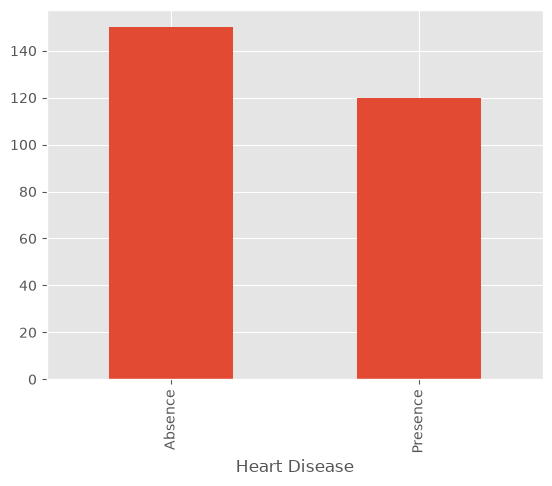

In [382]:
# ============================================================
# Target Variable
# ============================================================

print("=" * 50)
print("Target Variable Distribution")
print("=" * 50)
print(df["Heart Disease"].value_counts().plot(kind="bar"))

## Encode categorical values into numerical values


In [383]:
df['Heart Disease']= pd.get_dummies(df['Heart Disease'],drop_first=True,dtype=int)

df.head()

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,1
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,0
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,1
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,0
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,0


## Box-Plots 

In [384]:
columns_for_boxplotting=['Age', 'BP', 'Cholesterol', 'Max HR', 'ST depression']
columns_for_boxplotting

['Age', 'BP', 'Cholesterol', 'Max HR', 'ST depression']

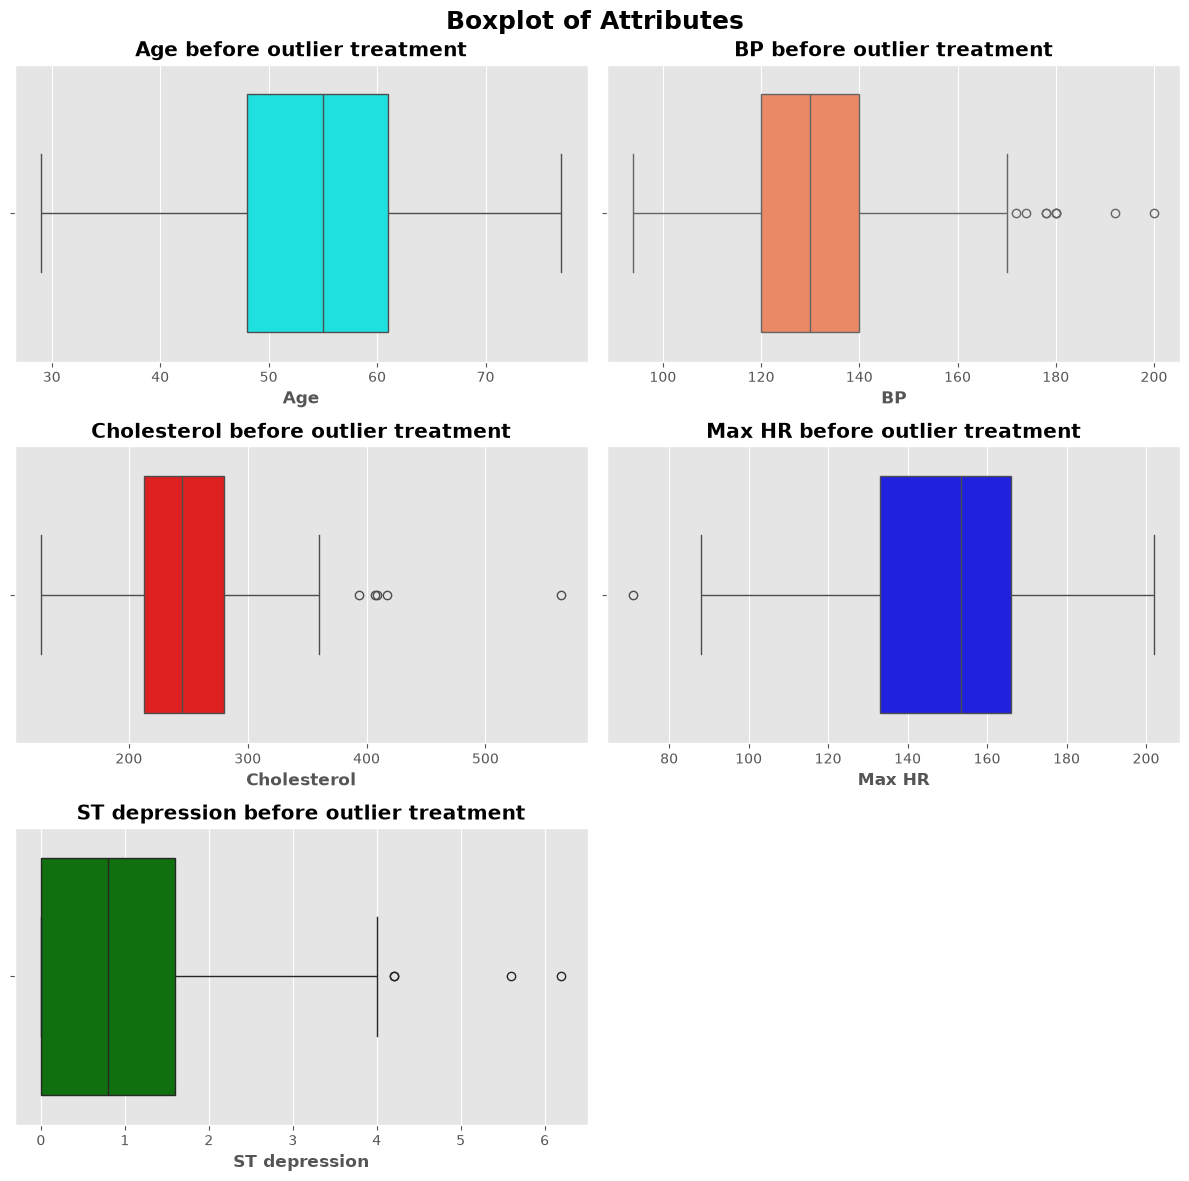

In [385]:
def box_plots():
    fig,axes=plt.subplots(3,2,figsize=(12,12))
    colours=['cyan','coral','red','blue','green']
    axes=axes.flatten()
    plt.delaxes(axes[-1])

    for index in range(len(columns_for_boxplotting)):
        sns.boxplot(x=df[columns_for_boxplotting[index]],ax=axes[index],color=colours[index])
        axes[index].set_xlabel(f'{columns_for_boxplotting[index]}',fontweight='bold')
        axes[index].set_title(f"{columns_for_boxplotting[index]} before outlier treatment", fontweight='bold')

    plt.suptitle("Boxplot of Attributes",fontweight='bold',fontsize=18)
    plt.tight_layout()
    plt.show()
    
box_plots()

### OMG: Outliers are there. Now we have to remove them!

In [386]:
for index in range(len(columns_for_boxplotting)):
    Q1 = df[columns_for_boxplotting[index]].quantile(0.25)
    Q3 = df[columns_for_boxplotting[index]].quantile(0.75)

    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    df[columns_for_boxplotting[index]] = df[columns_for_boxplotting[index]].clip(
        lower=lower_limit, upper=upper_limit
    )
print("Outlier removal accomplished!")

Outlier removal accomplished!


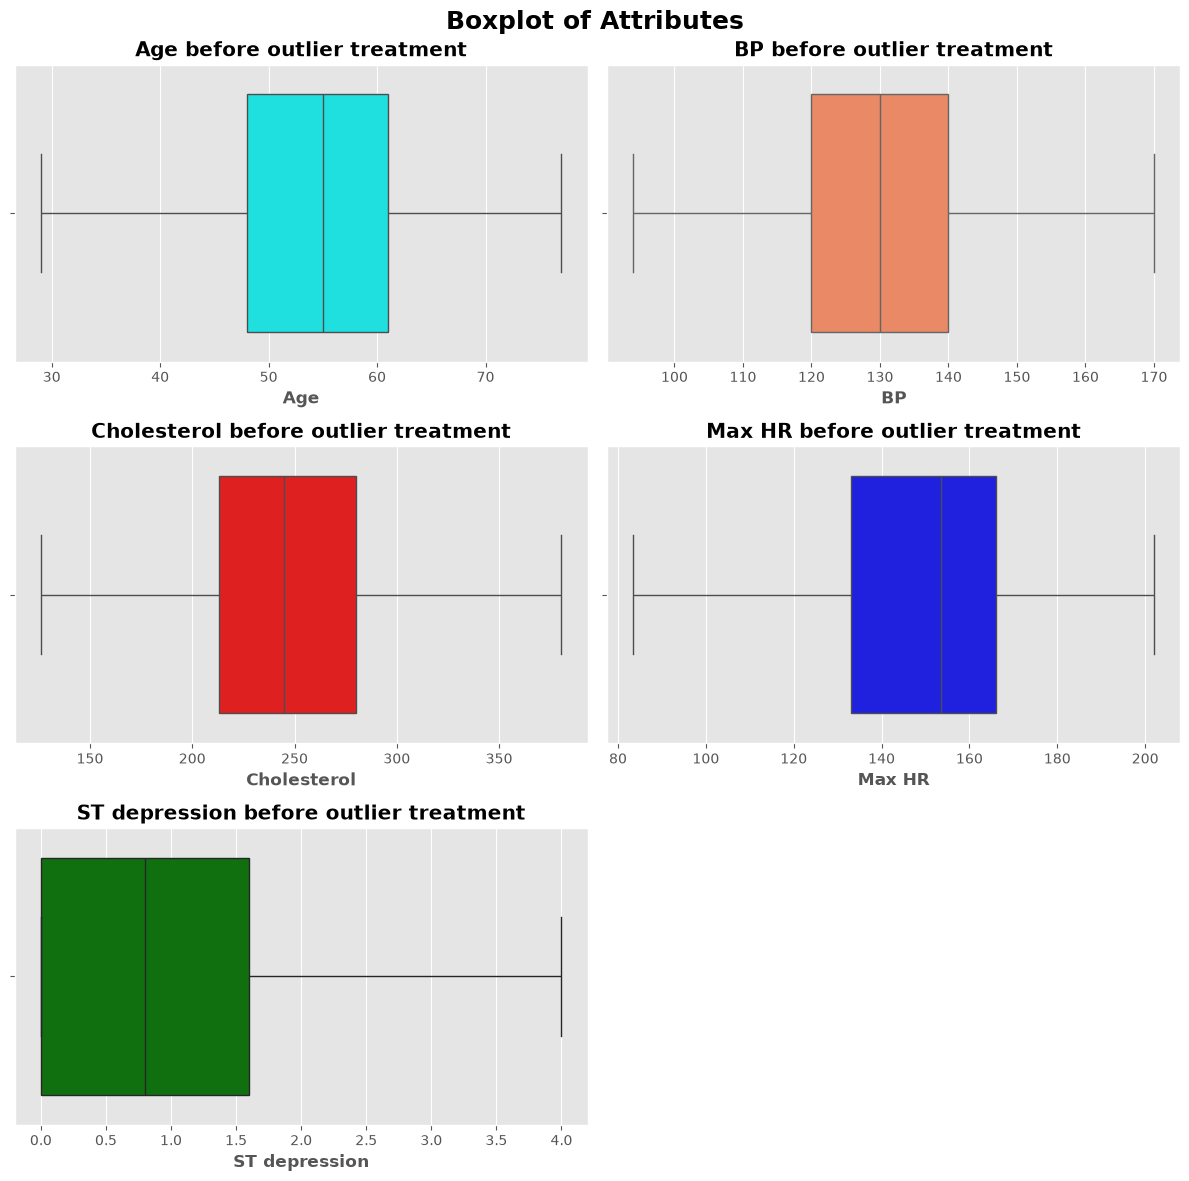

In [387]:
box_plots()

### One hot Encoding for certain attributes before feeding in the model

In [388]:
df=pd.concat([df,pd.get_dummies(df['Thallium'],prefix='Thallium',drop_first=True,dtype=int)],axis=1)
df=df.drop(columns=['Thallium'])

In [389]:
df=pd.concat([df,pd.get_dummies(df['Chest pain type'],prefix='Chest pain type',drop_first=True,dtype=int)],axis=1)
df=df.drop(columns=['Chest pain type'])

In [390]:
df=pd.concat([df,pd.get_dummies(df['EKG results'],prefix='EKG results',drop_first=True,dtype=int)],axis=1)
df=df.drop(columns=['EKG results'])

In [391]:
df=pd.concat([df,pd.get_dummies(df['Slope of ST'],prefix='Slope of ST',drop_first=True,dtype=int)],axis=1)
df=df.drop(columns=['Slope of ST'])

In [392]:
df=pd.concat([df,pd.get_dummies(df['Number of vessels fluro'],prefix='Number of vessels fluro',drop_first=True,dtype=int)],axis=1)
df=df.drop(columns=['Number of vessels fluro'])
df

,Age,Sex,BP,Cholesterol,FBS over 120,Max HR,Exercise angina,ST depression,Heart Disease,Thallium_6,...,Chest pain type_2,Chest pain type_3,Chest pain type_4,EKG results_1,EKG results_2,Slope of ST_2,Slope of ST_3,Number of vessels fluro_1,Number of vessels fluro_2,Number of vessels fluro_3
0,70,1,130,322.0,0,109.0,0,2.4,1,0,...,0,0,1,0,1,1,0,0,0,1
1,67,0,115,380.5,0,160.0,0,1.6,0,0,...,0,1,0,0,1,1,0,0,0,0
2,57,1,124,261.0,0,141.0,0,0.3,1,0,...,1,0,0,0,0,0,0,0,0,0
3,64,1,128,263.0,0,105.0,1,0.2,0,0,...,0,0,1,0,0,1,0,1,0,0
4,74,0,120,269.0,0,121.0,1,0.2,0,0,...,1,0,0,0,1,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
265,52,1,170,199.0,1,162.0,0,0.5,0,0,...,0,1,0,0,0,0,0,0,0,0
266,44,1,120,263.0,0,173.0,0,0.0,0,0,...,1,0,0,0,0,0,0,0,0,0
267,56,0,140,294.0,0,153.0,0,1.3,0,0,...,1,0,0,0,1,1,0,0,0,0
268,57,1,140,192.0,0,148.0,0,0.4,0,1,...,0,0,1,0,0,1,0,0,0,0


# Step 3: Feature Design

Feature Design (also called Feature Selection or Feature Engineering) is the process of selecting the input variables that will be used to train the machine learning model.

For **Task 1**, we will use only one feature:

- **Input Feature (X):** Cholesterol
- **Target Variable (y):** HeartDisease

### Why Cholesterol?

High cholesterol can contribute to the buildup of fatty deposits inside blood vessels. These deposits can reduce blood flow and increase the risk of cardiovascular diseases such as heart attacks and strokes.

Therefore, cholesterol is considered a relevant predictor for heart disease.

In [393]:
# ============================================================
# Feature Selection
# ============================================================

# Select the input feature
X = df[["Cholesterol"]]

# Select the target variable
y = df["Heart Disease"]

print("Feature Shape :", X.shape)
print("Target Shape  :", y.shape)

print("\nFirst Five Feature Values")

display(X.head())

print("\nFirst Five Target Values")

display(y.head())

Feature Shape : (270, 1)
Target Shape  : (270,)

First Five Feature Values


,Cholesterol
0,322.0
1,380.5
2,261.0
3,263.0
4,269.0



First Five Target Values


0    1
1    0
2    1
3    0
4    0
Name: Heart Disease, dtype: int64

# Step 4: Algorithm Selection

For this classification problem, we choose **Logistic Regression**.

## Why Logistic Regression?

- The target variable (`Heart Disease`) has only two possible outcomes:
  - `0` → Absence
  - `1` → Presence

- Logistic Regression is specifically designed for **binary classification** problems.

- Instead of predicting a continuous value, Logistic Regression predicts the **probability** that an observation belongs to a particular class.

- The predicted probability is converted into a class label using a threshold (usually **0.5**).

### Logistic Regression Equation

The linear equation is:

$$
z = w_0 + w_1x
$$

where:

- $w_0$ = Intercept (Bias)
- $w_1$ = Coefficient (Weight)
- $x$ = Input Feature

The sigmoid function converts this linear output into a probability:

$$
P(y=1)=\frac{1}{1+e^{-z}}
$$

The output probability always lies between **0 and 1**, making Logistic Regression suitable for binary classification.

# Step 5: Loss Function Selection

Logistic Regression uses **Binary Cross-Entropy Loss**, also called **Log Loss**.

The Binary Cross-Entropy Loss is defined as:

$$
Loss = -\frac{1}{N}\sum_{i=1}^{N}
\left[
y_i\log(p_i)+(1-y_i)\log(1-p_i)
\right]
$$

where:

- $y_i$ = Actual class (0 or 1)
- $p_i$ = Predicted probability
- $N$ = Number of samples

## Why Binary Cross-Entropy?

- It measures how close the predicted probabilities are to the true labels.
- Lower loss indicates better predictions.
- During training, Logistic Regression adjusts its parameters (weights and intercept) to minimize this loss.

# Step 6: Model Learning (Training)

The dataset will now be divided into:

- **Training Set (80%)**
- **Testing Set (20%)**

The model learns from the training data and is evaluated on the unseen testing data.

This helps estimate how well the model generalizes to new data.

In [394]:
# ============================================================
# Split Dataset into Training and Testing Sets
# ============================================================

from sklearn.model_selection import train_test_split

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("=" * 50)
print("Training and Testing Data Shapes")
print("=" * 50)

print(f"X_train : {X_train.shape}")
print(f"X_test  : {X_test.shape}")
print(f"y_train : {y_train.shape}")
print(f"y_test  : {y_test.shape}")

Training and Testing Data Shapes
X_train : (216, 1)
X_test  : (54, 1)
y_train : (216,)
y_test  : (54,)


### Checking stratify working efficiency

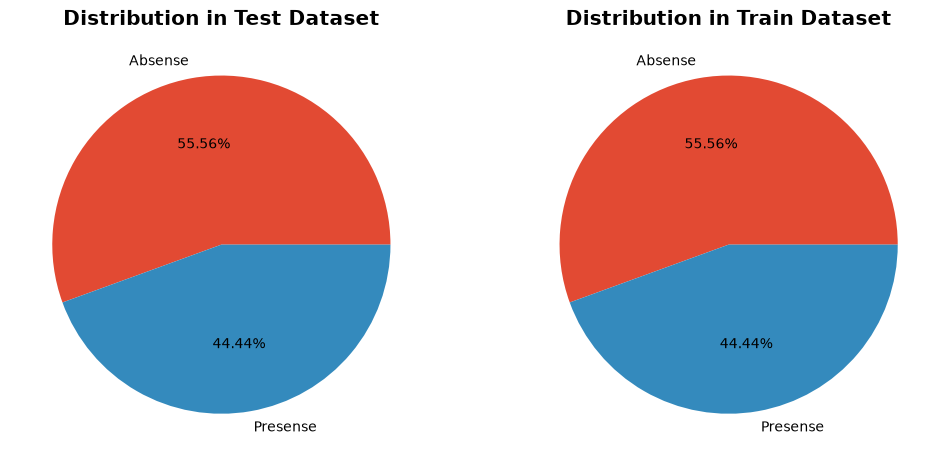

In [395]:
fig,axes=plt.subplots(1,2,figsize=(12,8))

axes[0].pie(y_test.value_counts(),labels=['Absense','Presense'],autopct= '%.2f%%')
axes[0].set_title("Distribution in Test Dataset",fontweight='bold')

axes[1].pie(y_train.value_counts(),labels=['Absense','Presense'],autopct= '%.2f%%')
axes[1].set_title("Distribution in Train Dataset",fontweight='bold')
plt.show()

In [396]:
# ============================================================
# Standardize Features
# ============================================================

scaler = StandardScaler()

# Learn scaling parameters from training data
X_train_scaled_single = scaler.fit_transform(X_train)

# Apply the same scaling to testing data
X_test_scaled_single = scaler.transform(X_test)

print("Feature scaling completed.")

Feature scaling completed.


In [397]:
# ============================================================
# Train Logistic Regression Model
# ============================================================

# Create the Logistic Regression model
log_reg_single = LogisticRegression(random_state=42)

# Train the model
log_reg_single.fit(X_train_scaled_single, y_train)

print("=" * 50)
print("Model Training Completed Successfully")
print("=" * 50)

Model Training Completed Successfully


In [398]:
# ============================================================
# Model Parameters
# ============================================================

print("=" * 50)
print("Intercept (Bias)")
print("=" * 50)

print(log_reg_single.intercept_[0])

print("\n")

print("=" * 50)
print("Coefficient (Weight)")
print("=" * 50)

print(log_reg_single.coef_[0][0])

Intercept (Bias)
-0.22560845171966262


Coefficient (Weight)
0.2269584729938641


## Interpretation of Model Parameters

The trained Logistic Regression model learns two important parameters:

### Intercept (Bias)

The intercept represents the model's baseline prediction when the cholesterol value is zero.

### Coefficient (Weight)

The coefficient indicates how cholesterol influences the probability of heart disease.

- **Positive coefficient**
  - Increasing cholesterol increases the probability of heart disease.

- **Negative coefficient**
  - Increasing cholesterol decreases the probability of heart disease.

The magnitude of the coefficient indicates the strength of the relationship.

In [399]:
# ============================================================
# Make Predictions
# ============================================================

# Predict class labels
y_pred = log_reg_single.predict(X_test_scaled_single)

# Predict probabilities
y_prob = log_reg_single.predict_proba(X_test_scaled_single)

print("=" * 50)
print("First 10 Predicted Classes")
print("=" * 50)

print(y_pred[:10])

print("\n")

print("=" * 50)
print("First 10 Prediction Probabilities")
print("=" * 50)

print(y_prob[:10])

First 10 Predicted Classes
[0 0 0 0 0 0 0 0 0 1]


First 10 Prediction Probabilities
[[0.55272566 0.44727434]
 [0.58135814 0.41864186]
 [0.53826475 0.46173525]
 [0.57661859 0.42338141]
 [0.53947263 0.46052737]
 [0.59782331 0.40217669]
 [0.63458845 0.36541155]
 [0.52131365 0.47868635]
 [0.5718649  0.4281351 ]
 [0.48608866 0.51391134]]


# Step 7: Model Evaluation

Model evaluation measures how well the trained Logistic Regression model performs on unseen data.

The following classification metrics will be used:

- Accuracy
- Precision
- Recall
- F1-score
- Confusion Matrix

Each metric provides different insights into the model's performance.

In [400]:
# ============================================================
# Calculate Evaluation Metrics
# ============================================================

# Calculate evaluation metrics
accuracy_single = accuracy_score(y_test, y_pred)
precision_single = precision_score(y_test, y_pred)
recall_single = recall_score(y_test, y_pred)
f1_single = f1_score(y_test, y_pred)

print("=" * 50)
print("Model Evaluation Metrics")
print("=" * 50)

print(f"Accuracy : {accuracy_single:.4f}")
print(f"Precision: {precision_single:.4f}")
print(f"Recall   : {recall_single:.4f}")
print(f"F1-Score : {f1_single:.4f}")

Model Evaluation Metrics
Accuracy : 0.5741
Precision: 0.5556
Recall   : 0.2083
F1-Score : 0.3030


In [401]:
# ============================================================
# Detailed Classification Report
# ============================================================

print("=" * 50)
print("Classification Report")
print("=" * 50)

print(classification_report(y_test, y_pred))

Classification Report
              precision    recall  f1-score   support

           0       0.58      0.87      0.69        30
           1       0.56      0.21      0.30        24

    accuracy                           0.57        54
   macro avg       0.57      0.54      0.50        54
weighted avg       0.57      0.57      0.52        54



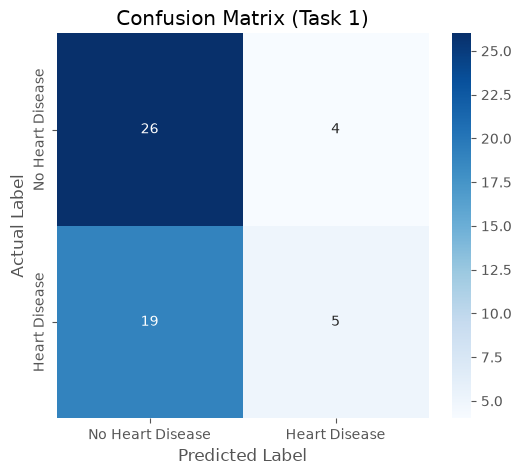

In [402]:
# ============================================================
# Confusion Matrix
# ============================================================

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Heart Disease", "Heart Disease"],
    yticklabels=["No Heart Disease", "Heart Disease"]
)

plt.title("Confusion Matrix (Task 1)")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

## Understanding the Confusion Matrix

A confusion matrix summarizes the model's predictions.

| Term | Meaning |
|------|----------|
| True Positive (TP) | Patient has heart disease and the model predicts heart disease correctly. |
| True Negative (TN) | Patient does not have heart disease and the model predicts no heart disease correctly. |
| False Positive (FP) | Patient does not have heart disease but the model predicts heart disease. |
| False Negative (FN) | Patient has heart disease but the model predicts no heart disease. |

A good classification model aims to maximize TP and TN while minimizing FP and FN.

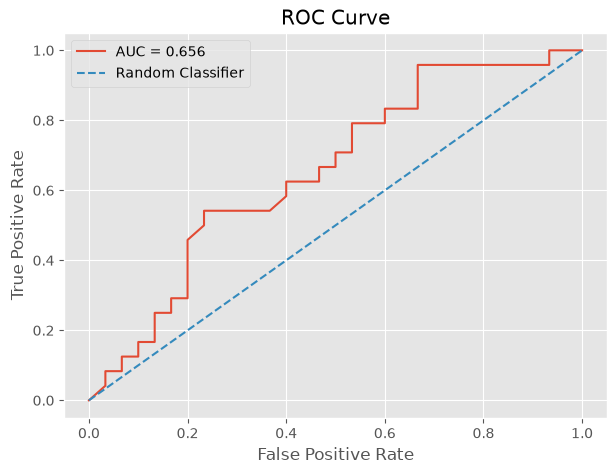

In [403]:
# Predict probabilities for the positive class
y_prob = log_reg_single.predict_proba(X_test_scaled_single)[:, 1]

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Compute Area Under the Curve (AUC)
roc_auc = auc(fpr, tpr)

# Plot ROC Curve
plt.figure(figsize=(7, 5))

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random Classifier")

plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)

plt.show()

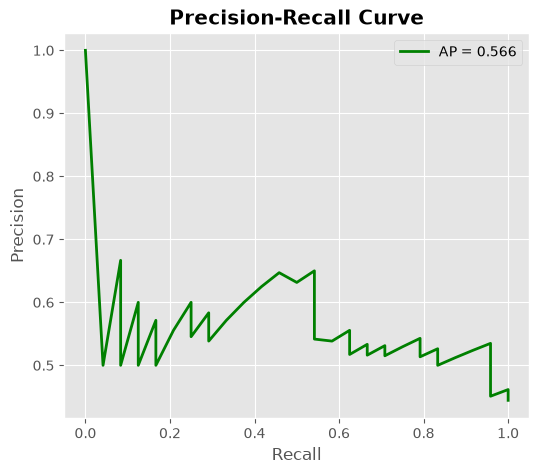

In [404]:
# Predict probabilities for the positive class
y_prob = log_reg_single.predict_proba(X_test_scaled_single)[:, 1]

# Compute Precision-Recall curve
precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

# Compute Average Precision (AP)
ap = average_precision_score(y_test, y_prob)

# Plot the curve
plt.figure(figsize=(6, 5))

plt.plot(recall, precision, lw=2, color="green", label=f"AP = {ap:.3f}")

plt.title("Precision-Recall Curve", fontweight="bold")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.grid(True)

plt.show()

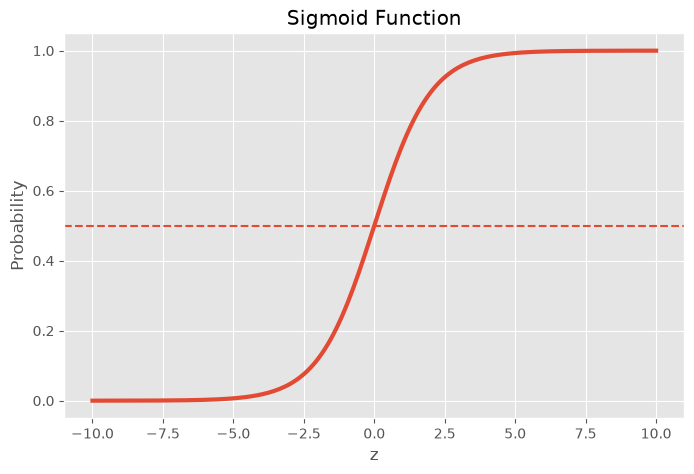

In [405]:
# ============================================================
# Plot the Sigmoid Curve
# ============================================================

# Generate a range of z values
z = np.linspace(-10, 10, 200)

# Compute sigmoid values
sigmoid = 1 / (1 + np.exp(-z))

plt.figure(figsize=(8,5))

plt.plot(z, sigmoid, linewidth=3)

plt.title("Sigmoid Function")
plt.xlabel("z")
plt.ylabel("Probability")

plt.grid(True)

# Decision threshold
plt.axhline(0.5, linestyle="--")

plt.show()

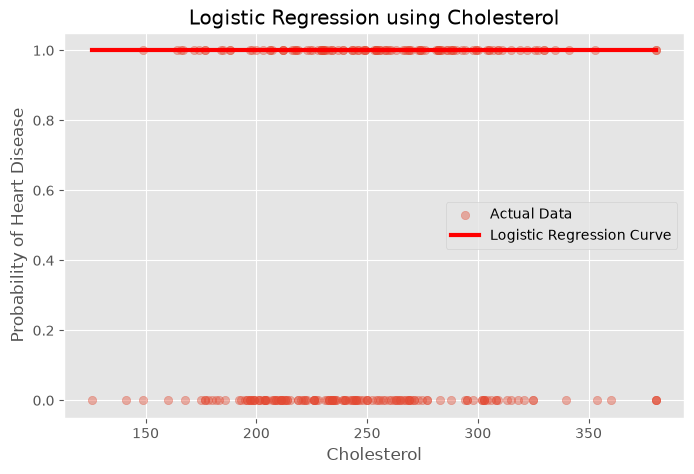

In [406]:
# ============================================================
# Logistic Regression Curve on Actual Data
# ============================================================

# Sort cholesterol values for smooth plotting
X_sorted = np.sort(X.values.reshape(-1, 1), axis=0)

# Predict probabilities
probabilities = log_reg_single.predict_proba(X_sorted)[:, 1]

plt.figure(figsize=(8,5))

# Actual observations
plt.scatter(
    X,
    y,
    alpha=0.4,
    label="Actual Data"
)

# Logistic regression curve
plt.plot(
    X_sorted,
    probabilities,
    color="red",
    linewidth=3,
    label="Logistic Regression Curve"
)

plt.xlabel("Cholesterol")
plt.ylabel("Probability of Heart Disease")

plt.title("Logistic Regression using Cholesterol")

plt.legend()

plt.show()

# Interpretation of Results

The Logistic Regression model was trained using only the **Cholesterol** feature.

After evaluating the model, we obtained the following metrics:

- **Accuracy** measures the overall percentage of correctly classified patients.
- **Precision** indicates how many patients predicted to have heart disease actually have it.
- **Recall** measures how effectively the model identifies patients with heart disease.
- **F1-score** provides a balanced measure of precision and recall.

Since this model uses only one feature, its predictive performance may be limited. Heart disease is influenced by multiple factors such as age, blood pressure, chest pain type, exercise-induced angina, and ECG results. Therefore, using additional relevant features is expected to improve classification performance.

# Task 2: Logistic Regression using Multiple Features

## Problem Statement

In this task, we will build a Logistic Regression model using **all available input features** to predict whether a patient has heart disease.

### Input Features
All columns except **Heart Disease**

### Target Variable
Heart Disease

Compared to Task 1, this model uses multiple medical attributes, allowing it to learn more complex relationships between patient characteristics and the presence of heart disease.

In [407]:
# ============================================================
# Select Features and Target
# ============================================================

# Select all columns except the target
X = df.drop(columns=["Heart Disease"])

# Target variable
y = df["Heart Disease"]

print("=" * 50)
print("Feature Matrix Shape")
print("=" * 50)
print(X.shape)

print("\n")

print("=" * 50)
print("Target Shape")
print("=" * 50)
print(y.shape)

print("\n")

display(X.head())

Feature Matrix Shape
(270, 20)


Target Shape
(270,)




,Age,Sex,BP,Cholesterol,FBS over 120,Max HR,Exercise angina,ST depression,Thallium_6,Thallium_7,Chest pain type_2,Chest pain type_3,Chest pain type_4,EKG results_1,EKG results_2,Slope of ST_2,Slope of ST_3,Number of vessels fluro_1,Number of vessels fluro_2,Number of vessels fluro_3
0,70,1,130,322.0,0,109.0,0,2.4,0,0,0,0,1,0,1,1,0,0,0,1
1,67,0,115,380.5,0,160.0,0,1.6,0,1,0,1,0,0,1,1,0,0,0,0
2,57,1,124,261.0,0,141.0,0,0.3,0,1,1,0,0,0,0,0,0,0,0,0
3,64,1,128,263.0,0,105.0,1,0.2,0,1,0,0,1,0,0,1,0,1,0,0
4,74,0,120,269.0,0,121.0,1,0.2,0,0,1,0,0,0,1,0,0,1,0,0


In [408]:
# ============================================================
# Train-Test Split
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Samples :", X_train.shape)
print("Testing Samples  :", X_test.shape)

Training Samples : (216, 20)
Testing Samples  : (54, 20)


In [409]:
# ============================================================
# Standardize Features
# ============================================================

scaler = StandardScaler()

# Learn scaling parameters from training data
X_train_scaled_multi = scaler.fit_transform(X_train)

# Apply the same scaling to testing data
X_test_scaled_multi = scaler.transform(X_test)

print("Feature scaling completed.")

Feature scaling completed.


In [410]:
# ============================================================
# Train Logistic Regression Model
# ============================================================

# Create the Logistic Regression model
log_reg_multi = LogisticRegression(random_state=42)

# Train the model using scaled features
log_reg_multi.fit(X_train_scaled_multi, y_train)

print("=" * 50)
print("Model Training Completed Successfully")
print("=" * 50)

Model Training Completed Successfully


In [411]:
# ============================================================
# Display Model Parameters
# ============================================================

print("=" * 50)
print("Intercept")
print("=" * 50)

print(log_reg_multi.intercept_[0])

print("\n")

# Create a DataFrame of feature coefficients
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": log_reg_multi.coef_[0]
})

# Sort by absolute coefficient value
coef_df["Absolute Coefficient"] = coef_df["Coefficient"].abs()

coef_df = coef_df.sort_values(
    by="Absolute Coefficient",
    ascending=False
)

print("=" * 50)
print("Feature Coefficients")
print("=" * 50)

coef_df.head(15)

Intercept
-0.2817470014344787


Feature Coefficients


,Feature,Coefficient,Absolute Coefficient
12,Chest pain type_4,1.001166,1.001166
19,Number of vessels fluro_3,0.931181,0.931181
1,Sex,0.867901,0.867901
17,Number of vessels fluro_1,0.806322,0.806322
9,Thallium_7,0.679100,0.679100
18,Number of vessels fluro_2,0.676473,0.676473
15,Slope of ST_2,0.643674,0.643674
3,Cholesterol,0.431328,0.431328
2,BP,0.384391,0.384391
7,ST depression,0.365594,0.365594


## Interpretation of Coefficients

Each coefficient represents the influence of a feature on the probability of heart disease.

- A **positive coefficient** increases the probability of heart disease.
- A **negative coefficient** decreases the probability of heart disease.
- Features with larger absolute coefficient values generally have a stronger influence on the prediction.

Since the features were standardized, the coefficients can be compared more fairly.

In [412]:
# ============================================================
# Make Predictions
# ============================================================

# Predict class labels
y_pred_multi = log_reg_multi.predict(X_test_scaled_multi)

# Predict probabilities
y_prob_multi = log_reg_multi.predict_proba(X_test_scaled_multi)

print("=" * 50)
print("First 10 Predictions")
print("=" * 50)

print(y_pred_multi[:10])

print("\n")

print("=" * 50)
print("First 10 Prediction Probabilities")
print("=" * 50)

print(y_prob_multi[:10])

First 10 Predictions
[0 0 0 1 0 0 0 1 1 1]


First 10 Prediction Probabilities
[[0.94320508 0.05679492]
 [0.84268975 0.15731025]
 [0.94081159 0.05918841]
 [0.13730979 0.86269021]
 [0.64604479 0.35395521]
 [0.96594368 0.03405632]
 [0.97750324 0.02249676]
 [0.00987505 0.99012495]
 [0.23906024 0.76093976]
 [0.23173183 0.76826817]]


In [413]:
# ============================================================
# Calculate Evaluation Metrics
# ============================================================

accuracy_multi = accuracy_score(y_test, y_pred_multi)
precision_multi = precision_score(y_test, y_pred_multi)
recall_multi = recall_score(y_test, y_pred_multi)
f1_multi = f1_score(y_test, y_pred_multi)

print("=" * 50)
print("Model Evaluation Metrics")
print("=" * 50)

print(f"Accuracy : {accuracy_multi:.4f}")
print(f"Precision: {precision_multi:.4f}")
print(f"Recall   : {recall_multi:.4f}")
print(f"F1-Score : {f1_multi:.4f}")

Model Evaluation Metrics
Accuracy : 0.8704
Precision: 0.8148
Recall   : 0.9167
F1-Score : 0.8627


In [414]:
# ============================================================
# Classification Report
# ============================================================

print(classification_report(y_test, y_pred_multi))

              precision    recall  f1-score   support

           0       0.93      0.83      0.88        30
           1       0.81      0.92      0.86        24

    accuracy                           0.87        54
   macro avg       0.87      0.88      0.87        54
weighted avg       0.88      0.87      0.87        54



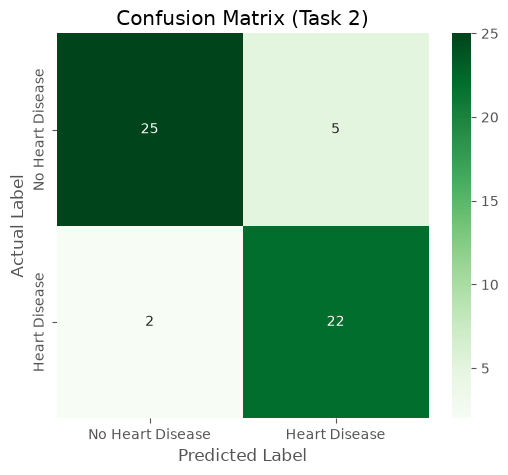

In [415]:
# ============================================================
# Confusion Matrix
# ============================================================

cm_multi = confusion_matrix(y_test, y_pred_multi)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_multi,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["No Heart Disease", "Heart Disease"],
    yticklabels=["No Heart Disease", "Heart Disease"]
)

plt.title("Confusion Matrix (Task 2)")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

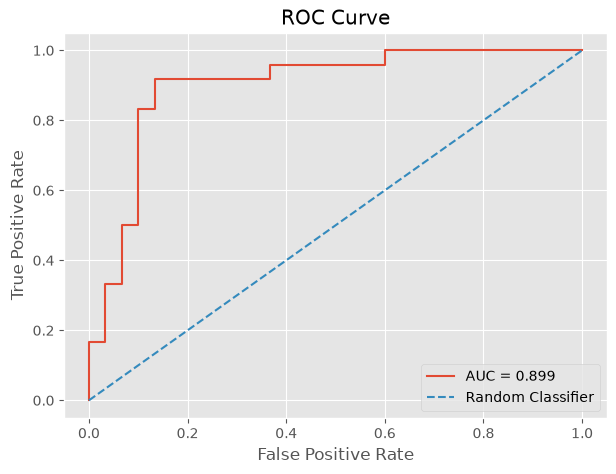

In [416]:
# Predict probabilities for the positive class
y_prob = log_reg_multi.predict_proba(X_test_scaled_multi)[:, 1]

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Compute Area Under the Curve (AUC)
roc_auc = auc(fpr, tpr)

# Plot ROC Curve
plt.figure(figsize=(7, 5))

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random Classifier")

plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)

plt.show()

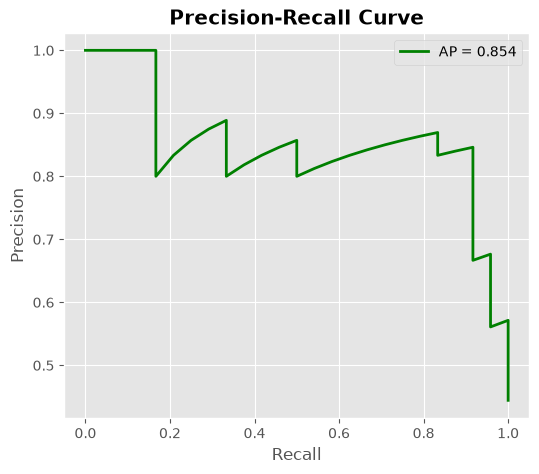

In [417]:
# Predict probabilities for the positive class
y_prob = log_reg_multi.predict_proba(X_test_scaled_multi)[:, 1]

# Compute Precision-Recall curve
precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

# Compute Average Precision (AP)
ap = average_precision_score(y_test, y_prob)

# Plot the curve
plt.figure(figsize=(6, 5))

plt.plot(recall, precision, lw=2, color="green", label=f"AP = {ap:.3f}")

plt.title("Precision-Recall Curve", fontweight="bold")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.grid(True)

plt.show()

# Model Comparison

In this section, we compare the performance of the two Logistic Regression models developed in this assignment.

- **Task 1:** Logistic Regression using only the **Cholesterol** feature.
- **Task 2:** Logistic Regression using **all available features**.

Comparing both models helps us understand the effect of using additional features on prediction performance.

In [418]:
# ============================================================
# Compare the Performance of Both Models
# ============================================================

comparison_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score"],
    "Task 1 (Cholesterol Only)": [
        accuracy_single,
        precision_single,
        recall_single,
        f1_single
    ],
    "Task 2 (All Features)": [
        accuracy_multi,
        precision_multi,
        recall_multi,
        f1_multi
    ]
})

# Display values up to 4 decimal places
comparison_df = comparison_df.round(4)

comparison_df

,Metric,Task 1 (Cholesterol Only),Task 2 (All Features)
0,Accuracy,0.5741,0.8704
1,Precision,0.5556,0.8148
2,Recall,0.2083,0.9167
3,F1-Score,0.3030,0.8627


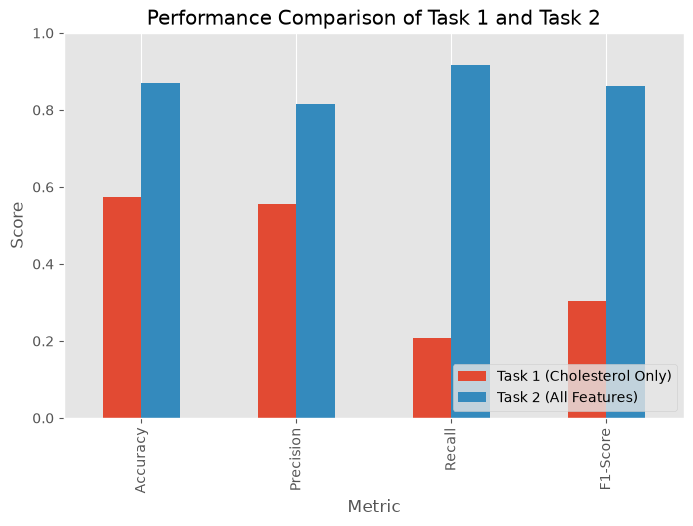

In [419]:
# ============================================================
# Visual Comparison of Model Performance
# ============================================================

comparison_plot = comparison_df.set_index("Metric")

comparison_plot.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Performance Comparison of Task 1 and Task 2")
plt.ylabel("Score")
plt.ylim(0, 1)

plt.grid(axis="y")

plt.legend(loc="lower right")

plt.show()

# Discussion

## Which model performs better?

The model trained using **all available features (Task 2)** performs better than the model trained using only the **Cholesterol** feature.

This is because heart disease is influenced by multiple medical factors rather than cholesterol alone.

---

## How does adding more features affect performance?

Using multiple features provides more information to the model.

As a result:

- Accuracy generally increases.
- Precision often improves because the model makes fewer incorrect positive predictions.
- Recall usually improves because the model identifies more patients with heart disease.
- F1-score increases due to a better balance between precision and recall.

---

## Trade-off between Interpretability and Performance

### Single-Feature Model

Advantages:

- Very easy to understand.
- Easy to visualize.
- Easy to explain to non-technical users.

Disadvantages:

- Limited predictive capability.
- Ignores many important medical factors.

---

### Multi-Feature Model

Advantages:

- Higher predictive performance.
- Uses more patient information.
- Better captures complex relationships.

Disadvantages:

- More difficult to interpret.
- Individual feature effects are harder to visualize.

# Conclusion

This assignment demonstrated the complete Machine Learning pipeline using Logistic Regression for heart disease prediction.

The following steps were successfully completed:

1. Data Retrieval and Collection
2. Data Cleaning
3. Feature Design
4. Algorithm Selection
5. Loss Function Selection
6. Model Learning (Training)
7. Model Evaluation

Two Logistic Regression models were developed:

- A single-feature model using only **Cholesterol**.
- A multi-feature model using all available features.

The results showed that the multi-feature model achieved better overall performance because it utilized more relevant medical information.

This assignment also demonstrated how Logistic Regression predicts probabilities using the sigmoid function and how classification metrics such as Accuracy, Precision, Recall, F1-score, and the Confusion Matrix can be used to evaluate classification models.